In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
n0 = 1.6
n2 = 10000
r = 1e-3
n = n0 - 0.5 * n2 * r*r
print(n)

1.5950000000000002


9448398.95816479


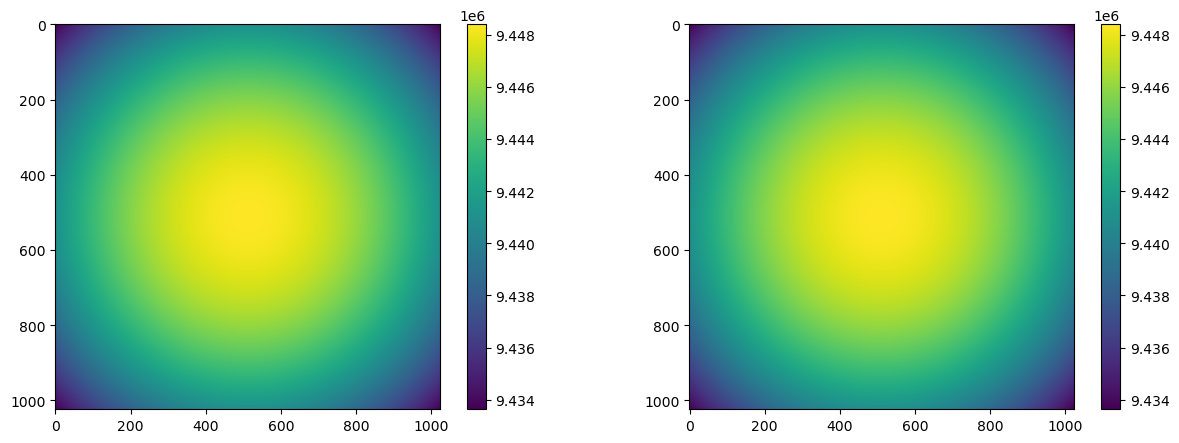

In [30]:
length = 1024
width = 1000e-6
wavelength = 1064e-9
fig, axes = plt.subplots(1,2, figsize=(15,5))
wavenumber = 2 * np.pi * n0 / wavelength
print(wavenumber)
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
k = wavenumber * (1 - 0.5 * n2 * (xx*xx + yy*yy) / n0)
# a = np.exp(0.5*n2/n0 * (xx*xx +yy*yy) * k * 1e-3)
im = axes[0].imshow(np.abs(k))
fig.colorbar(im, ax = axes[0])

wavenumber = 2*np.pi / wavelength
n = n0 - 0.5 * n2 * (xx*xx + yy*yy)
k = wavenumber * n
im = axes[1].imshow(k)
fig.colorbar(im, ax = axes[1])
plt.show()

In [31]:
angle = 2 * np.pi / 180.0
wavelength = 1064e-9
w0 = wavelength / (np.pi * np.tan(angle))
print(w0)

9.698575484700834e-06


In [32]:
1064e-6 / (np.pi * np.tan(angle)*np.tan(angle))

np.float64(0.27773086406336905)

In [33]:
np.sqrt(0.2777308641 * 1e-3 * wavelength / np.pi)

np.float64(9.698575485340423e-06)

In [34]:
wavelength / (np.pi * np.tan(angle)**2)

np.float64(0.000277730864063369)

In [35]:
np.pi * w0*w0 / wavelength

np.float64(0.00027773086406336904)

In [36]:
np.sqrt(0.000000001999469/1.6)

np.float64(3.5350645326500054e-05)

<Axes: >

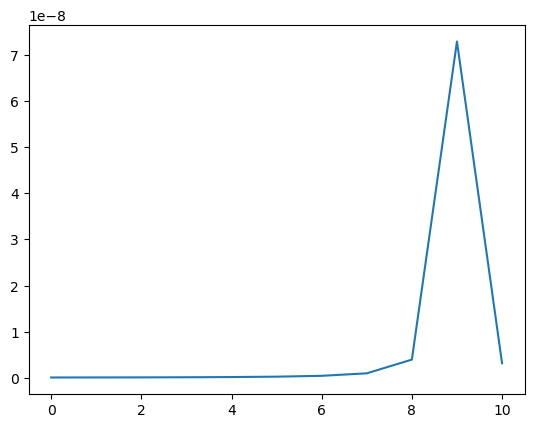

In [37]:
df = pd.read_csv("output.csv")
df["beam waist"].plot()
# df["beam waist"].plot()

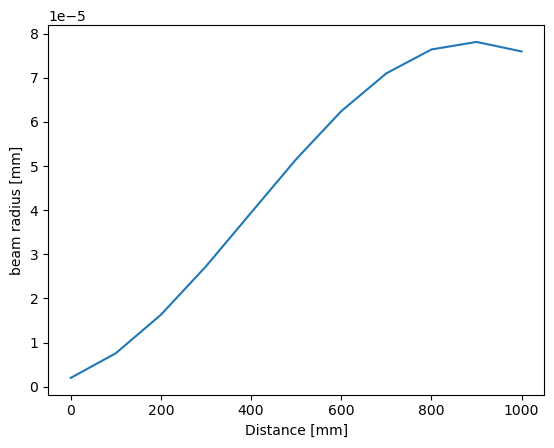

In [38]:
df = pd.read_csv("output.csv")
plt.plot(np.linspace(0, 1, df.index.size)*1000, df["beam radius"]*1000)
plt.ylabel("beam radius [mm]")
plt.xlabel("Distance [mm]")
plt.show()
# df["beam waist"].plot()

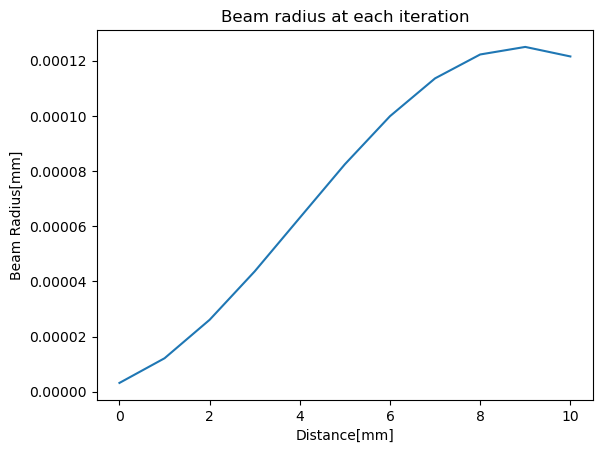

In [39]:
q_real = df["q param real"]
q_imag = df["q param imag"]
radius = (1064e-9 / np.pi) * (q_imag + (q_real*q_real)/q_imag)
# radius = (500e-9 / np.pi) * q_imag
# print(radius)
plt.plot(np.arange(0, 11, 1), radius*1e3)
plt.ylabel("Beam Radius[mm]")
plt.xlabel("Distance[mm]")
plt.title("Beam radius at each iteration")
plt.show()

In [40]:
q_real = 0.001666152303400
q_imag = 0.000020854040332
# (500e-9 / np.pi) * ((q_imag + (q_real*q_real))/q_imag)
np.pi

3.141592653589793

0.11697783979216492 [511 511] [312 495]


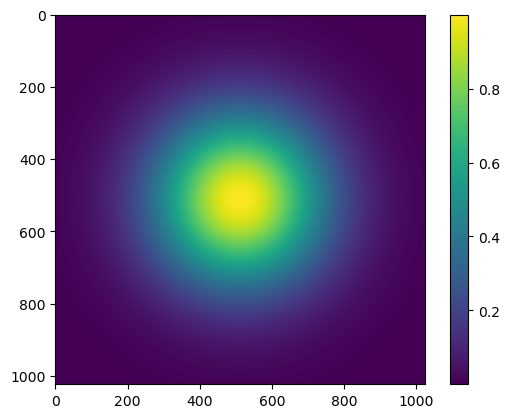

In [41]:
wSG = 0.0997186335
width = 0.3
length = 1024
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
k = 2*np.pi/wavelength
R = 2.0385672164

E = np.exp(-(xx*xx + yy*yy)/(wSG*wSG))
E = E*np.exp(-1j*k*(xx*xx+yy*yy)/(2*R))
Y = np.abs(E)**2
half_max = np.max(Y) / 2.0
maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
fwhm=(np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length
print(fwhm, maxIndex, left_idx)
plt.imshow(Y)
plt.colorbar()
plt.show()

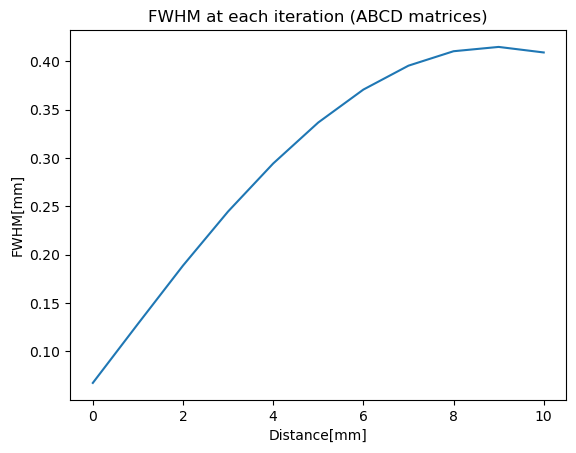

In [42]:
fwhm = []
length = 1024
width = 1000e-6
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
# y = np.linspace(-width/2, width/2, length)
for i in range(0,df.index.size):
    q_real = df.iloc[i]["q param real"]
    q_imag = df.iloc[i]["q param imag"]
    q = q_real + 1j*q_imag
    qr = 1/((1/q).real)
    qi = -1/((1/q).imag)
    Y = np.abs((1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real - 0.002 + ((xx*xx + yy*yy) / (2 * (q))))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real + ((x*x) / (2 * (q))))))**2             # FWHM 1D
    half_max = np.max(Y) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm.append((np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length) #return the difference (full width)
fwhm = np.array(fwhm)*1e3
plt.plot(np.arange(0, df.index.size, 1), fwhm)
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.title("FWHM at each iteration (ABCD matrices)")
plt.show()


In [43]:
print(np.array(fwhm))
# print(np.array(fwhm)/np.sqrt(2))

[0.06743233 0.12844674 0.18872686 0.24464011 0.29424202 0.3366238
 0.37063088 0.39534743 0.41027249 0.41472529 0.40899202]


In [44]:
fwhm_1D = np.array([0.08251953, 0.12353516, 0.16455078, 0.20556641, 0.24658203, 0.28759766, 0.32861328, 0.36962891, 0.41064453, 0.45166016, 0.49267578])
fwhm_2D = np.array([0.08272729, 0.12358243, 0.16456889, 0.20559482, 0.24664052, 0.28771742, 0.32878881, 0.36986394, 0.41096054, 0.45204112, 0.493144])
fwhm_2D_1_6 = np.array([0.06743233, 0.09767578, 0.12943782, 0.1618621, 0.19415674, 0.22669716, 0.25905978, 0.29154602, 0.32397157, 0.3563744, 0.38891226])
# fwhm, UGB, n0=1.6, n2=0.01, modified k with k*n
# [0.065089,0.0974429,0.130897,0.163177,0.195785,0.22766,0.261273,0.293756,0.328024,0.368242,0.39357]
# fwhm_2D_gaussian = np.array([0.06743233 0.09730405 0.12844674 0.1594042  0.18872686 0.21735921 0.24464011 0.27023798 0.29424202 0.31655692 0.3366238 ])
# fwhm from ugblocks code with ABS(val-max*0.5)
fwhm_ugb_05 = np.array([0.118746,0.176777,0.232497,0.288842,0.350631,0.404434,0.463056,0.519996,0.577895,0.635593,0.693524])

In [45]:
0.065089,0.0962213,0.128405,0.157573,0.185222,0.212695,0.235222,0.257384,0.278147,0.294047,0.303656
0.0643921,0.0983088,0.127475,0.159506,0.186838,0.213743,0.238389,0.260042,0.278962,0.294797,0.305688
0.0643921,0.0988501,0.126696,0.158547,0.18561,0.215058,0.239728,0.26162,0.280352,0.296961,0.307627

(0.0643921,
 0.0988501,
 0.126696,
 0.158547,
 0.18561,
 0.215058,
 0.239728,
 0.26162,
 0.280352,
 0.296961,
 0.307627)

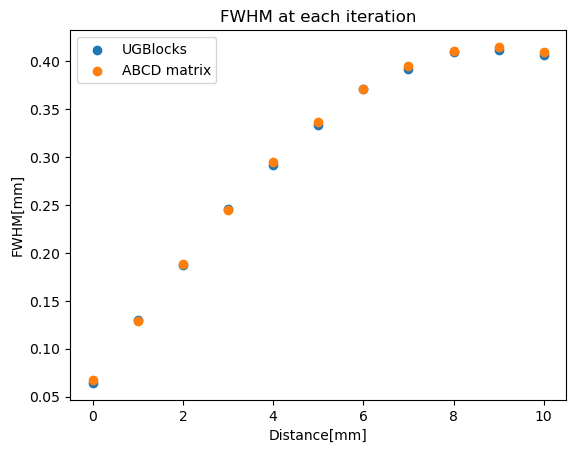

In [47]:
# fwhm_ugb = np.array([0.0820841,0.121976,0.166244,0.203626,0.243607,0.285258,0.328429,0.368583,0.409361,0.450372,0.49066])
fwhm_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/fwhm.csv', delimiter=',', dtype=float)
plt.scatter(np.arange(0, 11, 1), fwhm_ugb, label="UGBlocks")
plt.scatter(np.arange(0, 11, 1), fwhm, label="ABCD matrix")
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.title("FWHM at each iteration")
plt.legend()
plt.show()

0.00209873207405216 56.56103023313754


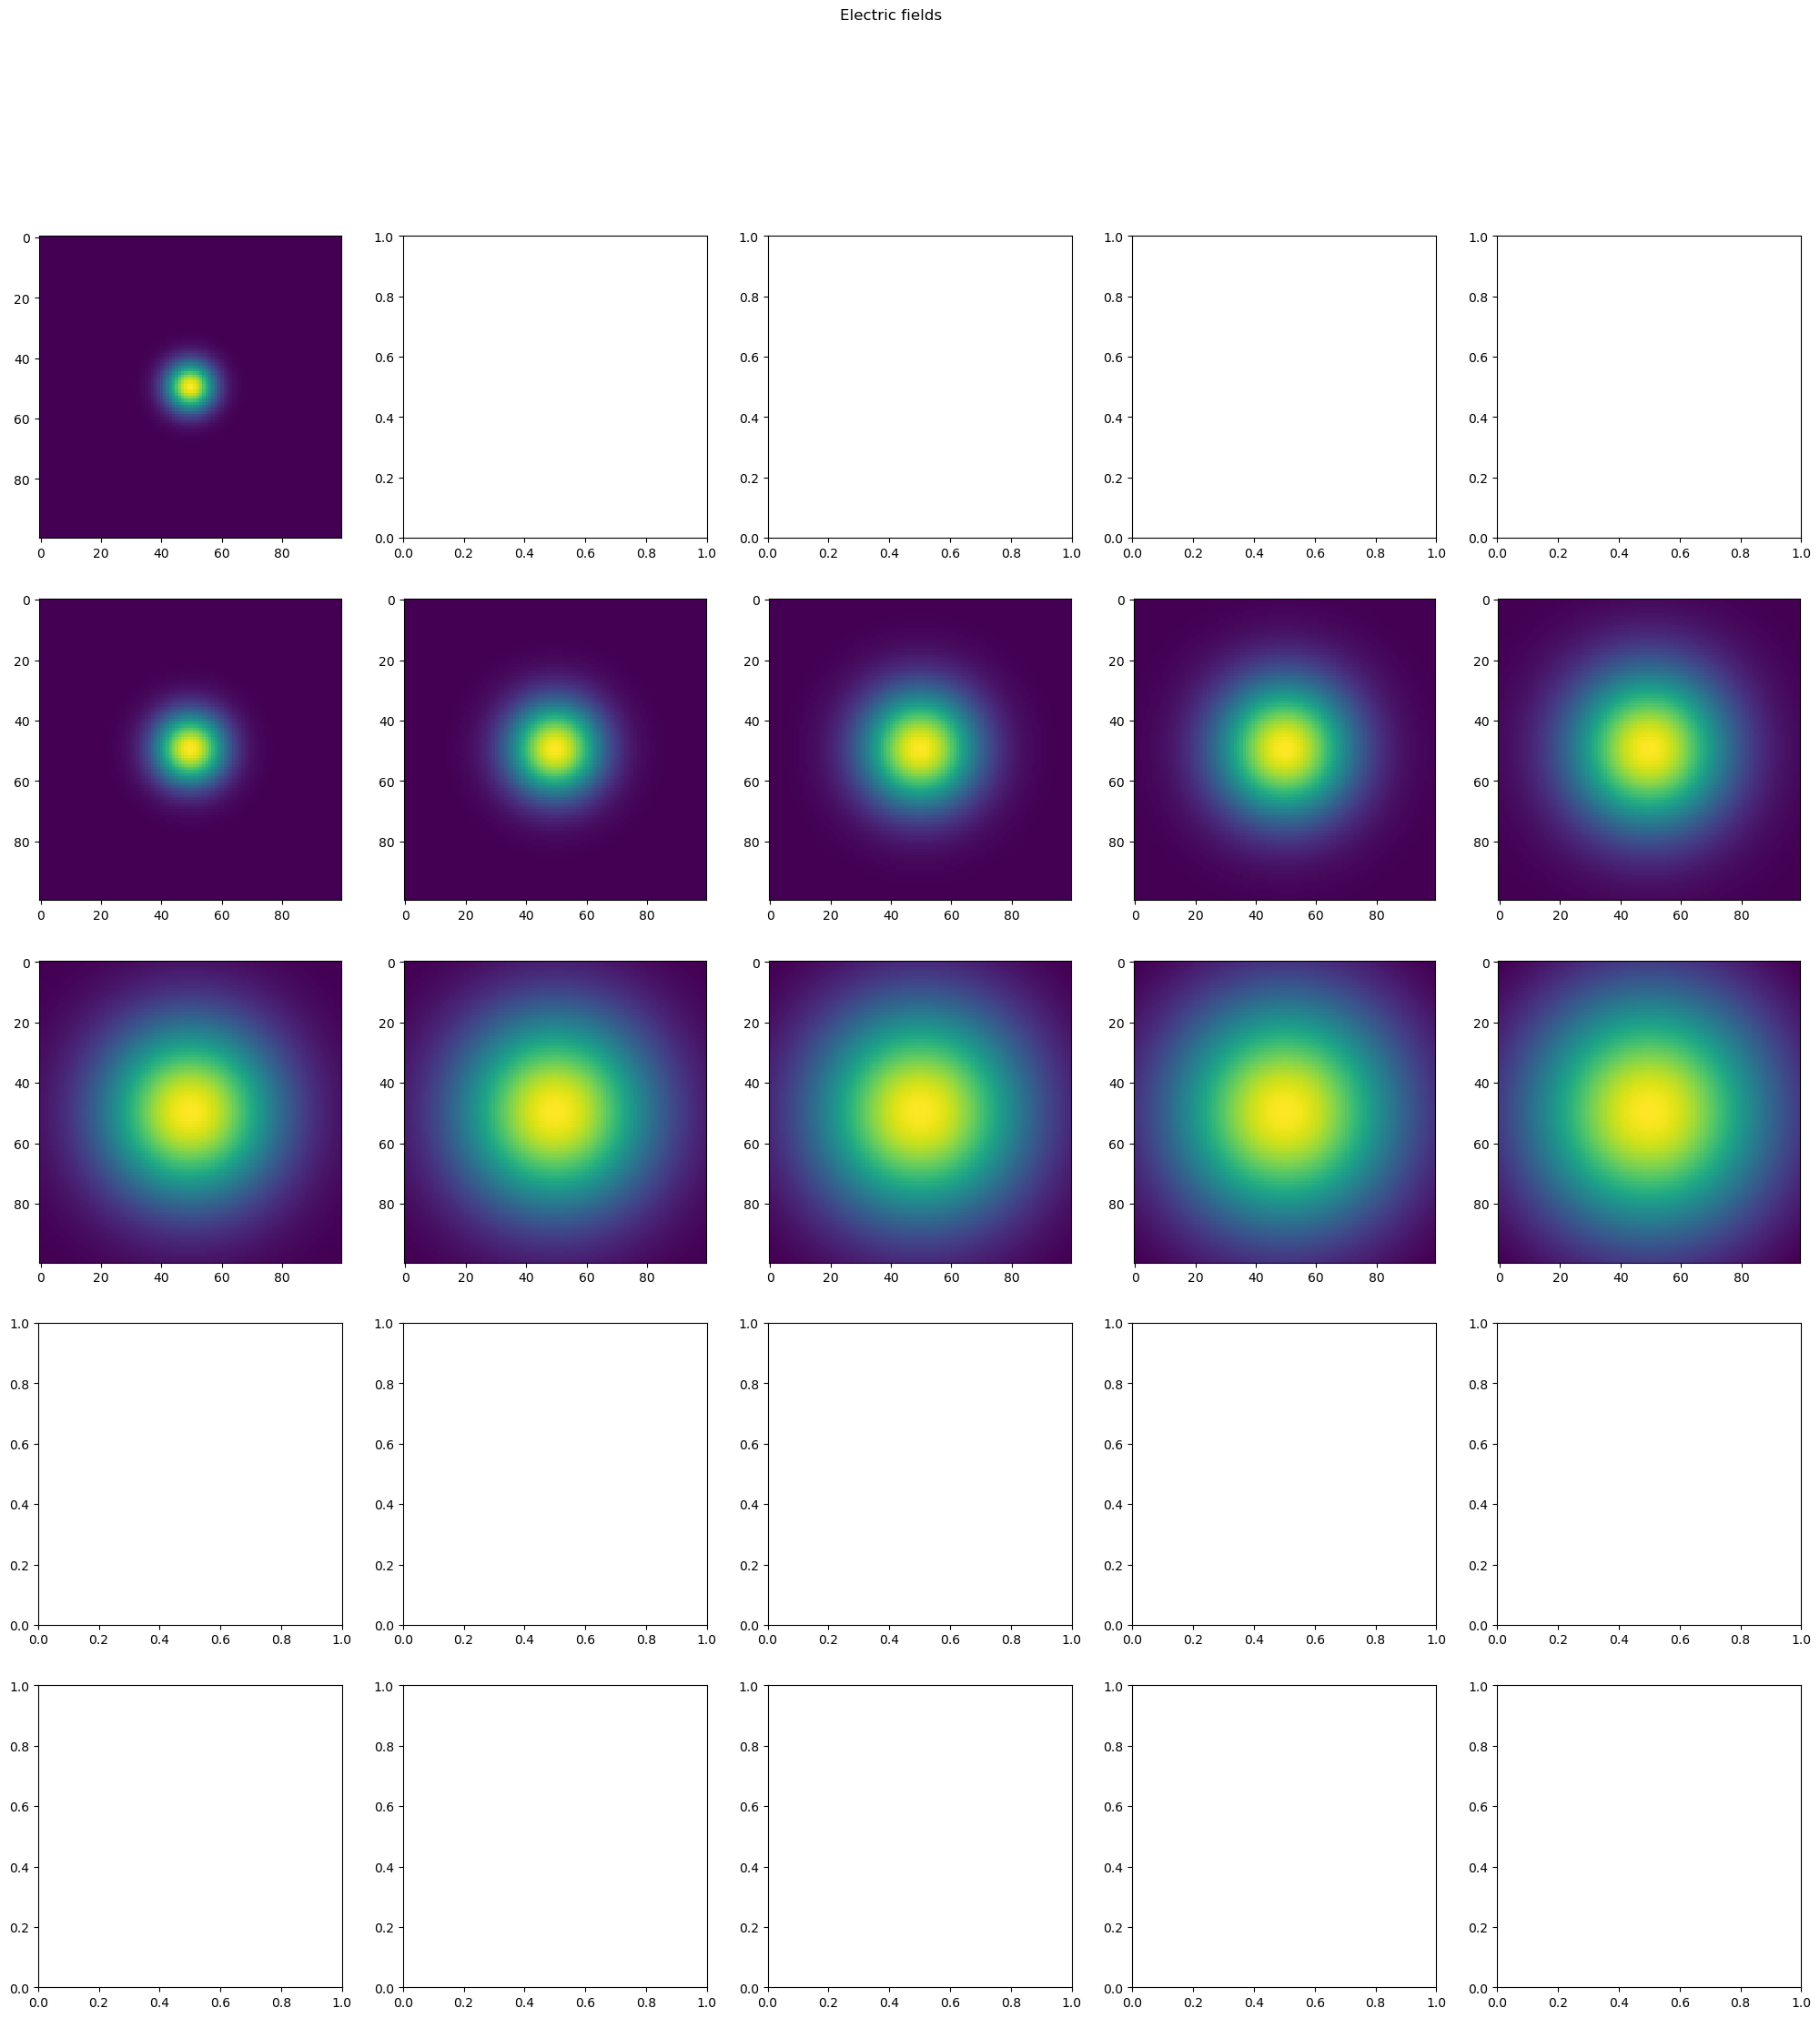

In [ ]:
# Plotting electric field

"""A_0*q_0 = 1"""

width = 1000e-6
x = np.linspace(-width/2, width/2, 100)
y = np.linspace(-width/2, width/2, 100)
xx, yy = np.meshgrid(x,y)
k = 2*np.pi/wavelength

fig, axes = plt.subplots(5, 5)
fig.set_figheight(25)
fig.set_figwidth(25)
plt.suptitle("Electric fields")

q_real = df.iloc[0]["q param real"]
q_imag = df.iloc[0]["q param imag"]
q = q_real + 1j*q_imag
# E = (1/(q)) * np.exp(-1j * k * (q_real + ((xx*xx + yy*yy) / (2 * (q)))))
qr = 1/((1/q).real)
qi = -1/((1/q).imag)
print(qr, np.sqrt(2*qi/k)*1e6)
E = (1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi)))    # FWHM 2D
axes[0, 0].imshow(np.abs(E)**2)
for i in range(1,df.index.size):
    q_real = df.iloc[i]["q param real"]
    q_imag = df.iloc[i]["q param imag"]
    q = q_real + 1j*q_imag
    qr = 1/((1/q).real)
    qi = -1/((1/q).imag)
    E = (1/(q)) * np.exp((-1j * k * (xx*xx + yy*yy)/(2*qr)) - (k*(xx*xx + yy*yy)/(2*qi)))    # FWHM 2D

    # E = (1/(q)) * np.exp(-1j * k * (q_real + ((xx*xx + yy*yy) / (2 * (q)))))
    axes[(i+4)//5, (i-1)%5].imshow(np.abs(E)**2)

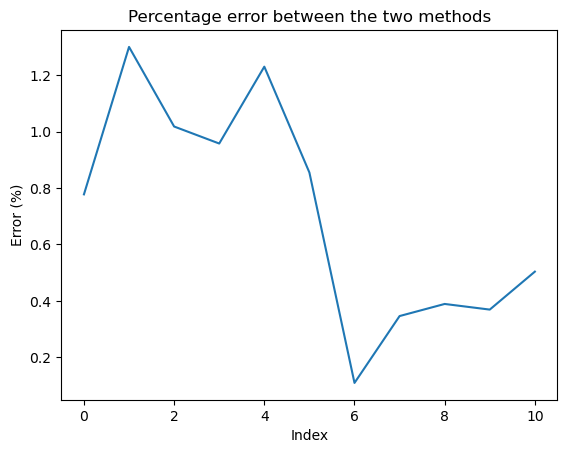

In [31]:
plt.plot(np.abs(fwhm_ugb - fwhm)/fwhm * 100)
plt.ylabel("Error (%)")
plt.xlabel("Index")
plt.title("Percentage error between the two methods")
plt.show()

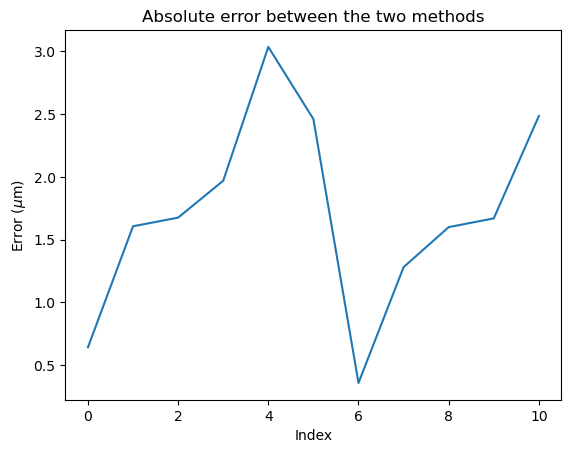

In [39]:
plt.plot(np.abs(fwhm_ugb - fwhm)*1000)
plt.ylabel(r"Error ($\mu$m)")
plt.xlabel("Index")
plt.title("Absolute error between the two methods")
plt.show()

In [93]:
# Test with quadratic function 4 - (x^2 + y^2). Max = 4, Halfmax = 2, fwhm = 2*sqrt(2) = 2.8284271247461903
# length = 1024
diff = []
for i in range(9, 14):
    length = 2**i
    width = 4
    x = np.linspace(-width/2, width/2, length)
    y = np.linspace(-width/2, width/2, length)
    xx, yy = np.meshgrid(x,y)

    F = 4 - xx*xx - yy*yy   # 2D
    # plt.imshow(F)

    # F = 4 - x*x             # 1D
    # plt.plot(F)

    # plt.show()

    half_max = np.max(F) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(F), F.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(F > half_max), F.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length #return the difference (full width)

    # print(f"Max: {np.max(F)}, Half Max: {half_max}, FWHM: {fwhm}")
    diff.append(np.sqrt(8) - fwhm)
    # print(f"Difference = {diff}, Percentage difference = {perc_diff}")
perc_diff = (diff / np.sqrt(8) * 100)


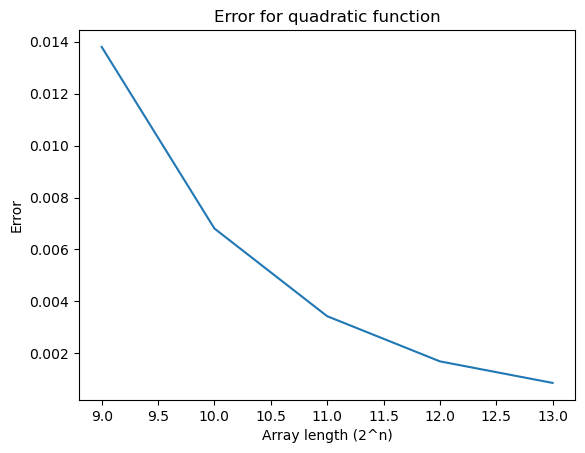

In [96]:
plt.plot(range(9, 14), np.array(diff))
plt.xlabel("Array length (2^n)")
plt.ylabel("Error")
plt.title("Error for quadratic function")
plt.show()

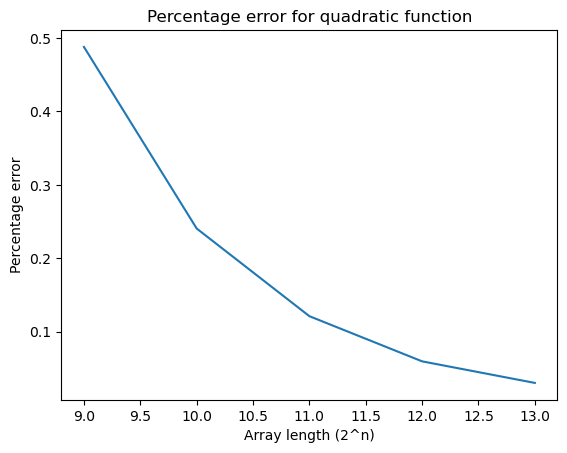

In [97]:
plt.plot(range(9, 14), np.array(perc_diff))
plt.xlabel("Array length (2^n)")
plt.ylabel("Percentage error")
plt.title("Percentage error for quadratic function")
plt.show()

In [92]:
np.sqrt(8)

np.float64(2.8284271247461903)